# Pertemuan 12: Asosiasi Data dan Sistem Rekomendasi Dasar

**Mata Kuliah:** Data Science (200302305)
**Program Studi:** PJJ Informatika, Semester 4
**Dosen Pengampu:** Syahid Abdullah, S.Si, M.Kom

| Keterangan | Isi |
| --- | --- |
| Nama Lengkap | [ISI NAMA LENGKAP ANDA] |
| NIM | [ISI NIM ANDA] |
| Kelas | [ISI KELAS ANDA] |

**Topik:** Algoritma Apriori (Market Basket Analysis) serta Konsep Collaborative Filtering dan Content-Based Filtering


## 1. Tujuan Praktikum

1. Memahami konsep support, confidence, dan lift pada aturan asosiasi.
2. Menerapkan algoritma Apriori untuk analisis keranjang belanja.
3. Membaca aturan asosiasi dan menerjemahkannya menjadi tindakan bisnis.
4. Membangun sistem rekomendasi sederhana memakai Collaborative Filtering.
5. Membangun sistem rekomendasi memakai Content-Based Filtering dengan TF-IDF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print('Pustaka berhasil dimuat.')

Pustaka berhasil dimuat.


## 2. Membangun Data Transaksi

Algoritma Apriori diterapkan pada data transaksi minimarket yang dibangkitkan secara
terprogram dengan seed tetap. Setiap transaksi berisi beberapa produk yang dibeli
bersamaan. Beberapa pola pembelian bersama sengaja ditanamkan, misalnya roti dengan
selai, kopi dengan gula, serta mi instan dengan telur, agar algoritma memiliki pola
nyata untuk ditemukan.

Perlu ditegaskan bahwa algoritma tidak diberi tahu pola tersebut. Menemukan kembali
pola itu dari data mentah justru menjadi tujuan analisis.

In [2]:
produk = [
    'Roti', 'Selai', 'Mentega', 'Susu', 'Kopi', 'Gula', 'Teh',
    'Mi Instan', 'Telur', 'Beras', 'Minyak Goreng', 'Sabun Mandi',
    'Shampo', 'Air Mineral', 'Cokelat'
]

# Pola pembelian bersama yang ditanamkan beserta peluang kemunculannya
pola = [
    (['Roti', 'Selai'], 0.20),
    (['Roti', 'Mentega'], 0.14),
    (['Kopi', 'Gula'], 0.22),
    (['Teh', 'Gula'], 0.12),
    (['Mi Instan', 'Telur'], 0.18),
    (['Beras', 'Minyak Goreng'], 0.15),
    (['Sabun Mandi', 'Shampo'], 0.13),
    (['Susu', 'Roti'], 0.10),
]

n_transaksi = 1500
transaksi = []

for _ in range(n_transaksi):
    keranjang = set()
    for isi, peluang in pola:
        if rng.random() < peluang:
            keranjang.update(isi)
    # Menambahkan beberapa produk acak sebagai derau
    tambahan = rng.integers(0, 4)
    if tambahan:
        keranjang.update(rng.choice(produk, size=int(tambahan), replace=False))
    if len(keranjang) < 2:
        keranjang.update(rng.choice(produk, size=2, replace=False))
    transaksi.append(sorted(keranjang))

print('Jumlah transaksi:', len(transaksi))
print('Rata rata jumlah produk per transaksi:',
      round(float(np.mean([len(t) for t in transaksi])), 2))
print()
print('Sepuluh transaksi pertama:')
for i, t in enumerate(transaksi[:10], start=1):
    print(f'  Transaksi {i:>2}: {", ".join(t)}')

Jumlah transaksi: 1500
Rata rata jumlah produk per transaksi: 3.91

Sepuluh transaksi pertama:
  Transaksi  1: Mi Instan, Selai, Shampo, Telur
  Transaksi  2: Beras, Minyak Goreng, Roti, Susu
  Transaksi  3: Air Mineral, Beras, Sabun Mandi, Shampo
  Transaksi  4: Beras, Cokelat, Minyak Goreng
  Transaksi  5: Selai, Shampo
  Transaksi  6: Roti, Selai
  Transaksi  7: Roti, Telur
  Transaksi  8: Mi Instan, Selai, Telur
  Transaksi  9: Beras, Mi Instan, Minyak Goreng, Sabun Mandi, Shampo, Teh, Telur
  Transaksi 10: Air Mineral, Selai


In [3]:
# Mengubah daftar transaksi menjadi tabel biner (format one hot)
tabel = pd.DataFrame(
    [[1 if p in t else 0 for p in produk] for t in transaksi],
    columns=produk
)

print('Ukuran tabel transaksi:', tabel.shape)
tabel.head(10)

Ukuran tabel transaksi: (1500, 15)


,Roti,Selai,Mentega,Susu,Kopi,Gula,Teh,Mi Instan,Telur,Beras,Minyak Goreng,Sabun Mandi,Shampo,Air Mineral,Cokelat
0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0
1,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0
3,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1
4,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
5,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
7,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0
8,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0
9,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


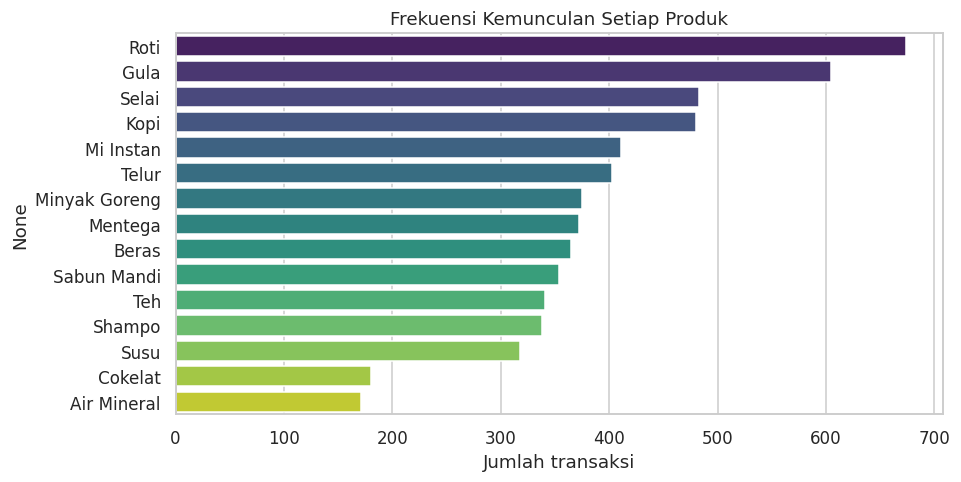

,support
Roti,0.449
Gula,0.403
Selai,0.322
Kopi,0.320
Mi Instan,0.274
Telur,0.269
Minyak Goreng,0.250
Mentega,0.248
Beras,0.243
Sabun Mandi,0.236


In [4]:
frekuensi = tabel.sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=frekuensi.values, y=frekuensi.index, hue=frekuensi.index,
            palette='viridis', legend=False)
plt.title('Frekuensi Kemunculan Setiap Produk')
plt.xlabel('Jumlah transaksi')
plt.show()

(frekuensi / len(tabel)).round(3).to_frame('support')

## 3. Konsep Dasar Aturan Asosiasi

Untuk sebuah aturan berbentuk `A -> B`, tiga ukuran utamanya adalah sebagai berikut.

**Support** adalah proporsi transaksi yang memuat A dan B sekaligus.
Support(A, B) = jumlah transaksi memuat A dan B dibagi total transaksi.
Ukuran ini menjawab seberapa sering pola tersebut muncul.

**Confidence** adalah peluang B dibeli bila A sudah ada di keranjang.
Confidence(A -> B) = Support(A, B) dibagi Support(A).
Ukuran ini menjawab seberapa dapat diandalkan aturan tersebut.

**Lift** adalah perbandingan Confidence terhadap Support B.
Lift(A -> B) = Confidence(A -> B) dibagi Support(B).
Nilai lift lebih dari satu berarti kehadiran A menaikkan peluang B dibeli, nilai satu
berarti keduanya saling bebas, dan nilai kurang dari satu berarti keduanya cenderung
saling meniadakan. Lift inilah ukuran yang paling penting karena confidence tinggi
bisa saja hanya disebabkan produk B memang laris untuk semua orang.

## 4. Implementasi Algoritma Apriori

Algoritma Apriori bekerja bertahap dengan memanfaatkan satu sifat penting, yaitu
**bila sebuah itemset tidak memenuhi support minimum, maka seluruh gabungan yang
memuatnya juga pasti tidak memenuhi**. Sifat ini membuat ruang pencarian dapat
dipangkas jauh lebih awal sehingga perhitungannya menjadi efisien.

Implementasi berikut ditulis langsung memakai numpy dan pandas tanpa pustaka tambahan,
supaya alur algoritmanya terlihat jelas dan notebook tetap dapat dijalankan di mana
saja tanpa perlu memasang paket lain.

In [5]:
def hitung_support(daftar_transaksi, itemset):
    """Menghitung support sebuah itemset terhadap seluruh transaksi."""
    target = set(itemset)
    cocok = sum(1 for t in daftar_transaksi if target.issubset(t))
    return cocok / len(daftar_transaksi)


def apriori(daftar_transaksi, min_support=0.05, maks_panjang=3):
    """Mencari seluruh itemset yang sering muncul memakai algoritma Apriori."""
    himpunan_transaksi = [set(t) for t in daftar_transaksi]
    semua_item = sorted({item for t in himpunan_transaksi for item in t})

    hasil = {}

    # Tahap pertama: itemset berukuran satu
    kandidat = [(item,) for item in semua_item]
    tingkat = 1

    while kandidat and tingkat <= maks_panjang:
        sering = {}
        for kombinasi in kandidat:
            sup = hitung_support(himpunan_transaksi, kombinasi)
            if sup >= min_support:
                sering[kombinasi] = sup

        if not sering:
            break

        hasil.update(sering)
        print(f'Tingkat {tingkat}: {len(kandidat)} kandidat diperiksa, '
              f'{len(sering)} itemset lolos support minimum')

        # Menyusun kandidat tingkat berikutnya hanya dari itemset yang lolos
        item_lolos = sorted({item for kombinasi in sering for item in kombinasi})
        tingkat += 1
        kandidat_baru = []
        for kombinasi in combinations(item_lolos, tingkat):
            # Pemangkasan: seluruh bagiannya harus sudah lolos pada tingkat sebelumnya
            if all(tuple(sorted(bagian)) in sering for bagian in combinations(kombinasi, tingkat - 1)):
                kandidat_baru.append(kombinasi)
        kandidat = kandidat_baru

    return hasil


MIN_SUPPORT = 0.05
itemset_sering = apriori(transaksi, min_support=MIN_SUPPORT, maks_panjang=3)

print()
print('Total itemset yang sering muncul:', len(itemset_sering))

Tingkat 1: 15 kandidat diperiksa, 15 itemset lolos support minimum
Tingkat 2: 105 kandidat diperiksa, 67 itemset lolos support minimum
Tingkat 3: 194 kandidat diperiksa, 32 itemset lolos support minimum

Total itemset yang sering muncul: 114


In [6]:
ringkas = pd.DataFrame([
    {'itemset': ', '.join(k), 'panjang': len(k), 'support': round(v, 4)}
    for k, v in itemset_sering.items()
]).sort_values(['panjang', 'support'], ascending=[True, False]).reset_index(drop=True)

print('Itemset berukuran dua dan tiga dengan support tertinggi:')
ringkas[ringkas['panjang'] >= 2].head(15)

Itemset berukuran dua dan tiga dengan support tertinggi:


,itemset,panjang,support
15,"Gula, Kopi",2,0.2413
16,"Roti, Selai",2,0.2360
17,"Mi Instan, Telur",2,0.1827
18,"Gula, Roti",2,0.1780
19,"Mentega, Roti",2,0.1653
20,"Beras, Minyak Goreng",2,0.1520
21,"Kopi, Roti",2,0.1413
22,"Sabun Mandi, Shampo",2,0.1413
23,"Roti, Susu",2,0.1400
24,"Gula, Teh",2,0.1380


## 5. Membentuk Aturan Asosiasi

In [7]:
def buat_aturan(itemset_sering, daftar_transaksi, min_confidence=0.35):
    """Membentuk aturan asosiasi dari itemset yang sering muncul."""
    himpunan_transaksi = [set(t) for t in daftar_transaksi]
    aturan = []

    for itemset, sup_gabungan in itemset_sering.items():
        if len(itemset) < 2:
            continue
        for ukuran in range(1, len(itemset)):
            for depan in combinations(itemset, ukuran):
                belakang = tuple(sorted(set(itemset) - set(depan)))
                sup_depan = itemset_sering.get(tuple(sorted(depan)))
                sup_belakang = itemset_sering.get(tuple(sorted(belakang)))
                if sup_depan is None:
                    sup_depan = hitung_support(himpunan_transaksi, depan)
                if sup_belakang is None:
                    sup_belakang = hitung_support(himpunan_transaksi, belakang)

                confidence = sup_gabungan / sup_depan
                if confidence < min_confidence:
                    continue

                aturan.append({
                    'jika_membeli': ', '.join(sorted(depan)),
                    'maka_membeli': ', '.join(belakang),
                    'support': round(sup_gabungan, 4),
                    'confidence': round(confidence, 4),
                    'lift': round(confidence / sup_belakang, 4),
                })

    return pd.DataFrame(aturan).sort_values('lift', ascending=False).reset_index(drop=True)


aturan = buat_aturan(itemset_sering, transaksi, min_confidence=0.35)
print('Jumlah aturan yang terbentuk:', len(aturan))
aturan.head(15)

Jumlah aturan yang terbentuk: 105


,jika_membeli,maka_membeli,support,confidence,lift
0,"Mentega, Mi Instan",Telur,0.0587,0.7652,2.8482
1,"Mentega, Telur",Mi Instan,0.0587,0.7652,2.7928
2,"Roti, Shampo",Sabun Mandi,0.0607,0.6547,2.7741
3,"Roti, Sabun Mandi",Shampo,0.0607,0.6190,2.7473
4,"Gula, Telur",Mi Instan,0.0747,0.7517,2.7433
5,"Gula, Minyak Goreng",Beras,0.0667,0.6579,2.7037
6,Shampo,Sabun Mandi,0.1413,0.6272,2.6577
7,Sabun Mandi,Shampo,0.1413,0.5989,2.6577
8,"Gula, Mi Instan",Telur,0.0747,0.7134,2.6552
9,"Beras, Gula",Minyak Goreng,0.0667,0.6579,2.6316


In [8]:
# Menyaring aturan yang benar benar bermakna, yaitu lift lebih besar dari satu
aturan_kuat = aturan[aturan['lift'] > 1.2].copy()
print('Jumlah aturan dengan lift di atas 1,2:', len(aturan_kuat))
aturan_kuat.head(10)

Jumlah aturan dengan lift di atas 1,2: 73


,jika_membeli,maka_membeli,support,confidence,lift
0,"Mentega, Mi Instan",Telur,0.0587,0.7652,2.8482
1,"Mentega, Telur",Mi Instan,0.0587,0.7652,2.7928
2,"Roti, Shampo",Sabun Mandi,0.0607,0.6547,2.7741
3,"Roti, Sabun Mandi",Shampo,0.0607,0.6190,2.7473
4,"Gula, Telur",Mi Instan,0.0747,0.7517,2.7433
5,"Gula, Minyak Goreng",Beras,0.0667,0.6579,2.7037
6,Shampo,Sabun Mandi,0.1413,0.6272,2.6577
7,Sabun Mandi,Shampo,0.1413,0.5989,2.6577
8,"Gula, Mi Instan",Telur,0.0747,0.7134,2.6552
9,"Beras, Gula",Minyak Goreng,0.0667,0.6579,2.6316


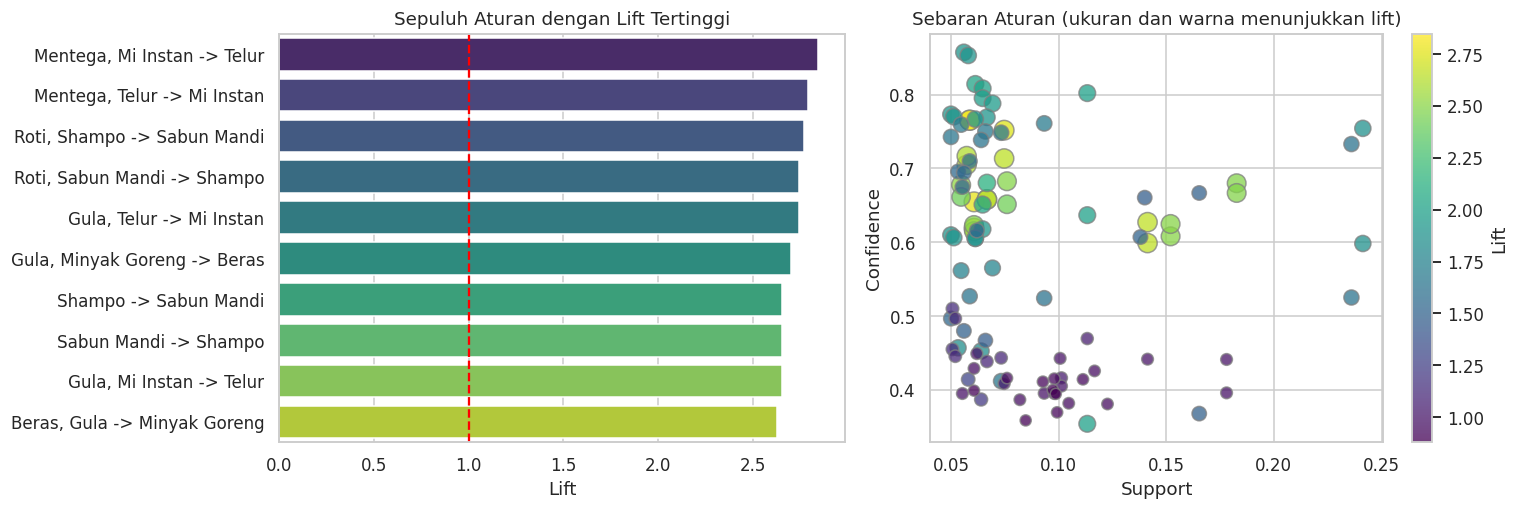

In [9]:
sepuluh = aturan_kuat.head(10).copy()
sepuluh['aturan'] = sepuluh['jika_membeli'] + ' -> ' + sepuluh['maka_membeli']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(data=sepuluh, x='lift', y='aturan', hue='aturan', palette='viridis',
            legend=False, ax=axes[0])
axes[0].axvline(1, linestyle='--', color='red')
axes[0].set_title('Sepuluh Aturan dengan Lift Tertinggi')
axes[0].set_xlabel('Lift')
axes[0].set_ylabel('')

sebaran = axes[1].scatter(aturan['support'], aturan['confidence'],
                          s=aturan['lift'] * 60, c=aturan['lift'],
                          cmap='viridis', alpha=0.75, edgecolors='grey')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Sebaran Aturan (ukuran dan warna menunjukkan lift)')
plt.colorbar(sebaran, ax=axes[1], label='Lift')

plt.tight_layout()
plt.show()

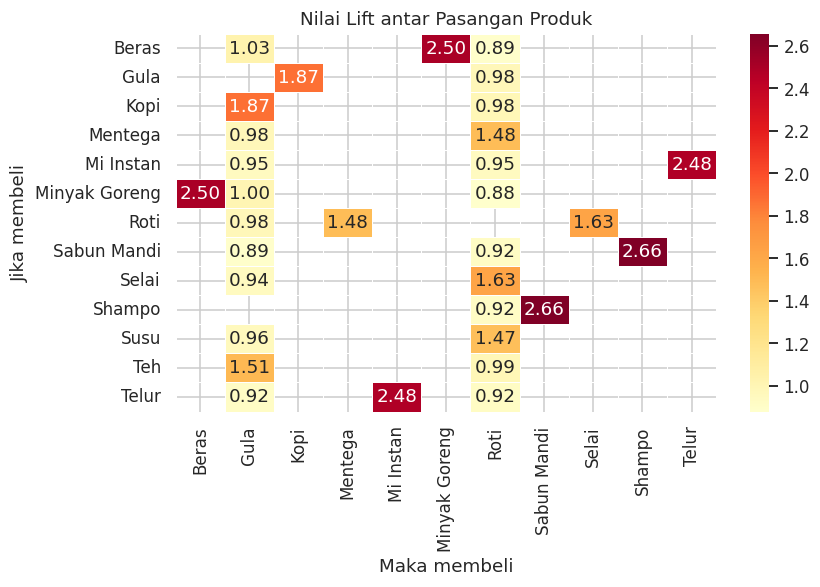

In [10]:
# Peta panas lift antar pasangan produk
pasangan = aturan[(aturan['jika_membeli'].str.count(',') == 0) &
                  (aturan['maka_membeli'].str.count(',') == 0)]

matriks = pasangan.pivot_table(index='jika_membeli', columns='maka_membeli',
                               values='lift', aggfunc='max')

plt.figure(figsize=(8, 5.5))
sns.heatmap(matriks, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Nilai Lift antar Pasangan Produk')
plt.xlabel('Maka membeli')
plt.ylabel('Jika membeli')
plt.tight_layout()
plt.show()

Daftar aturan dengan lift tertinggi didominasi oleh gabungan tiga produk, misalnya
mentega dengan mi instan yang mengarah ke telur. Hal ini wajar karena semakin banyak
syarat pada bagian kiri aturan, semakin sempit kelompok pembelinya sehingga
confidence-nya ikut naik. Sisi lain dari aturan semacam ini adalah support-nya kecil,
sehingga jumlah transaksi yang benar benar terpengaruh juga sedikit.

Peta panas di atas yang hanya memuat aturan antar dua produk memperlihatkan gambaran
yang lebih bersih. Pasangan dengan lift tertinggi berturut turut adalah shampo dengan
sabun mandi, beras dengan minyak goreng, mi instan dengan telur, kopi dengan gula,
roti dengan selai, teh dengan gula, serta mentega dengan roti. Ketujuh pasangan itu
persis sama dengan pola yang ditanamkan pada tahap pembuatan data, sehingga algoritma
Apriori terbukti berhasil menemukan kembali struktur yang benar tanpa diberi tahu
sebelumnya.

Penerapan praktisnya di minimarket antara lain penempatan rak berdekatan untuk produk
yang berpasangan, penawaran paket bundling, serta pemberian kupon produk pasangan
pada struk belanja.

## 6. Sistem Rekomendasi: Collaborative Filtering

Collaborative Filtering merekomendasikan sesuatu berdasarkan kemiripan pola penilaian
antar pengguna atau antar item, tanpa memperhatikan isi item itu sendiri. Prinsipnya
sederhana, yaitu bila dua pengguna menyukai item yang kurang lebih sama, maka item
yang disukai salah satunya berpeluang disukai yang lain.

Pada praktikum ini dibangun matriks penilaian pengguna terhadap film, kemudian
kemiripan dihitung memakai **cosine similarity**.

In [11]:
film = [
    'Laskar Pelangi', 'Pengabdi Setan', 'Habibie dan Ainun', 'Danur',
    'Ada Apa dengan Cinta', 'Sebelum Iblis Menjemput', 'Dilan 1990',
    'Perempuan Tanah Jahanam', 'Ayat Ayat Cinta', 'Impetigore',
]

pengguna = [f'Pengguna {i:02d}' for i in range(1, 21)]

# Dua kelompok selera: penggemar drama dan penggemar horor
suka_drama = [0, 2, 4, 6, 8]
suka_horor = [1, 3, 5, 7, 9]

data_nilai = []
for i, _ in enumerate(pengguna):
    baris = np.zeros(len(film))
    kelompok = suka_drama if i % 2 == 0 else suka_horor
    lawan = suka_horor if i % 2 == 0 else suka_drama

    for idx in kelompok:
        if rng.random() < 0.8:
            baris[idx] = rng.integers(4, 6)
    for idx in lawan:
        if rng.random() < 0.35:
            baris[idx] = rng.integers(1, 4)
    data_nilai.append(baris)

penilaian = pd.DataFrame(data_nilai, index=pengguna, columns=film)
print('Ukuran matriks penilaian:', penilaian.shape)
print('Tingkat kekosongan matriks:',
      f'{(penilaian == 0).sum().sum() / penilaian.size * 100:.1f} persen')
penilaian.head(8)

Ukuran matriks penilaian: (20, 10)
Tingkat kekosongan matriks: 46.5 persen


,Laskar Pelangi,Pengabdi Setan,Habibie dan Ainun,Danur,Ada Apa dengan Cinta,Sebelum Iblis Menjemput,Dilan 1990,Perempuan Tanah Jahanam,Ayat Ayat Cinta,Impetigore
Pengguna 01,5.0,0.0,4.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0
Pengguna 02,3.0,5.0,2.0,5.0,0.0,4.0,2.0,4.0,3.0,5.0
Pengguna 03,4.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0
Pengguna 04,3.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,3.0,5.0
Pengguna 05,5.0,3.0,4.0,2.0,4.0,3.0,5.0,0.0,4.0,0.0
Pengguna 06,2.0,5.0,0.0,0.0,3.0,5.0,1.0,5.0,2.0,5.0
Pengguna 07,4.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
Pengguna 08,0.0,5.0,0.0,5.0,0.0,5.0,0.0,4.0,0.0,4.0


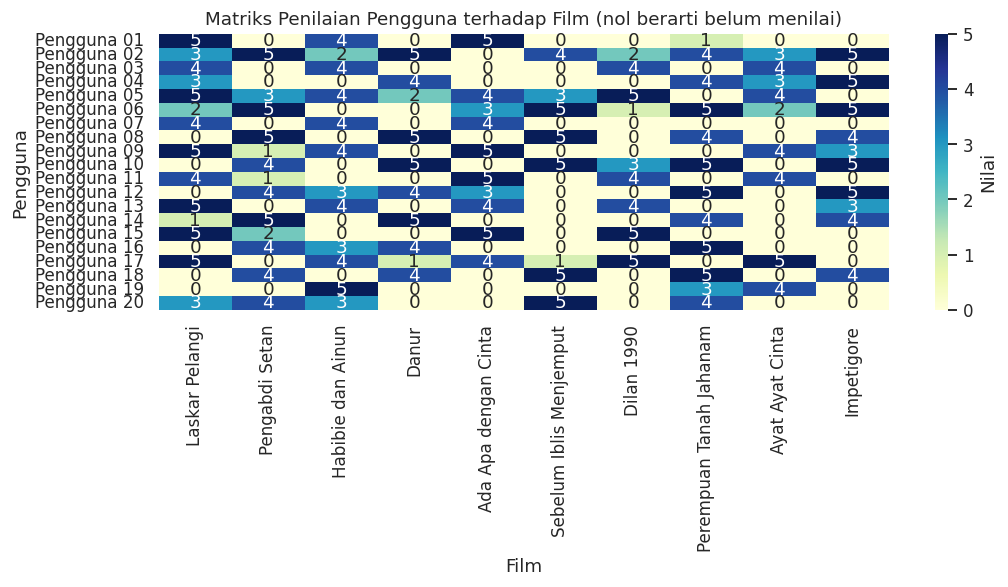

In [12]:
plt.figure(figsize=(10, 5.5))
sns.heatmap(penilaian, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Nilai'})
plt.title('Matriks Penilaian Pengguna terhadap Film (nol berarti belum menilai)')
plt.xlabel('Film')
plt.ylabel('Pengguna')
plt.tight_layout()
plt.show()

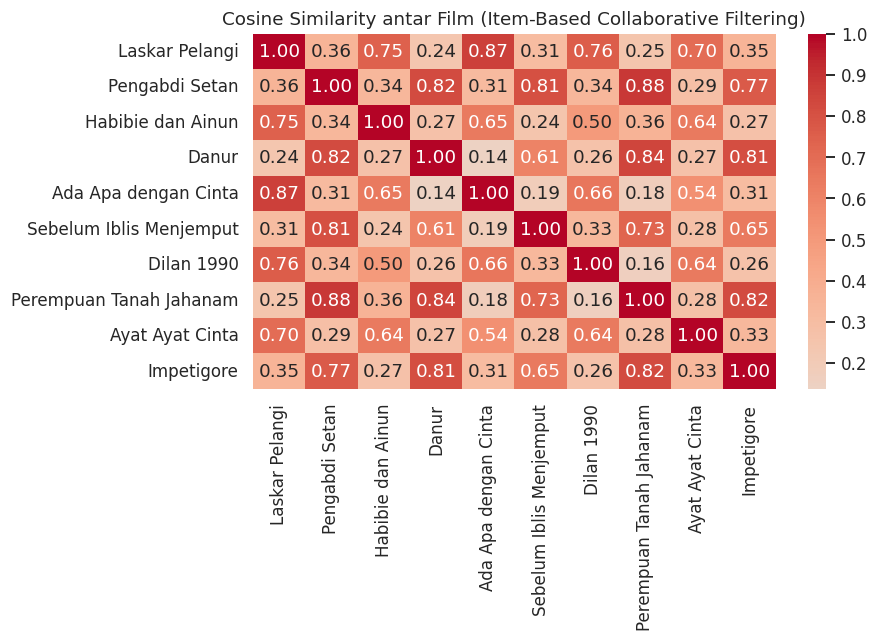

In [13]:
# Kemiripan antar item berdasarkan pola penilaian seluruh pengguna
kemiripan_item = pd.DataFrame(
    cosine_similarity(penilaian.T.values),
    index=film, columns=film
)

plt.figure(figsize=(8.5, 6))
sns.heatmap(kemiripan_item, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cosine Similarity antar Film (Item-Based Collaborative Filtering)')
plt.tight_layout()
plt.show()

In [14]:
def rekomendasi_collaborative(nama_pengguna, jumlah=3):
    """Merekomendasikan film memakai item based collaborative filtering."""
    nilai_pengguna = penilaian.loc[nama_pengguna]
    sudah_dinilai = nilai_pengguna[nilai_pengguna > 0]
    belum_dinilai = nilai_pengguna[nilai_pengguna == 0].index

    skor = {}
    for kandidat in belum_dinilai:
        pembilang = 0.0
        penyebut = 0.0
        for judul, nilai in sudah_dinilai.items():
            mirip = kemiripan_item.loc[kandidat, judul]
            pembilang += mirip * nilai
            penyebut += abs(mirip)
        skor[kandidat] = pembilang / penyebut if penyebut > 0 else 0.0

    hasil = pd.Series(skor).sort_values(ascending=False).head(jumlah)
    return hasil.round(3)


contoh = 'Pengguna 01'
print(f'Film yang sudah dinilai oleh {contoh}:')
print(penilaian.loc[contoh][penilaian.loc[contoh] > 0].to_string())
print()
print(f'Rekomendasi untuk {contoh} (perkiraan nilai):')
print(rekomendasi_collaborative(contoh).to_string())

Film yang sudah dinilai oleh Pengguna 01:
Laskar Pelangi             5.0
Habibie dan Ainun          4.0
Ada Apa dengan Cinta       5.0
Perempuan Tanah Jahanam    1.0

Rekomendasi untuk Pengguna 01 (perkiraan nilai):
Dilan 1990         4.446
Ayat Ayat Cinta    4.186
Impetigore         2.967


In [15]:
# Menampilkan rekomendasi untuk beberapa pengguna sekaligus
baris_hasil = []
for nama in pengguna[:6]:
    rek = rekomendasi_collaborative(nama, jumlah=2)
    baris_hasil.append({
        'pengguna': nama,
        'rekomendasi_1': rek.index[0] if len(rek) > 0 else '-',
        'skor_1': rek.iloc[0] if len(rek) > 0 else 0,
        'rekomendasi_2': rek.index[1] if len(rek) > 1 else '-',
        'skor_2': rek.iloc[1] if len(rek) > 1 else 0,
    })

pd.DataFrame(baris_hasil)

,pengguna,rekomendasi_1,skor_1,rekomendasi_2,skor_2
0,Pengguna 01,Dilan 1990,4.446,Ayat Ayat Cinta,4.186
1,Pengguna 02,Ada Apa dengan Cinta,3.149,-,0.000
2,Pengguna 03,Pengabdi Setan,4.000,Danur,4.000
3,Pengguna 04,Pengabdi Setan,4.041,Sebelum Iblis Menjemput,4.023
4,Pengguna 05,Impetigore,3.353,Perempuan Tanah Jahanam,3.216
5,Pengguna 06,Danur,4.284,Habibie dan Ainun,3.015


## 7. Sistem Rekomendasi: Content-Based Filtering

Berbeda dengan Collaborative Filtering, Content-Based Filtering merekomendasikan item
berdasarkan kemiripan **isi** item tersebut, misalnya genre, sinopsis, atau kata kunci.
Pendekatan ini tidak memerlukan data penilaian pengguna lain sehingga tetap bekerja
untuk item baru yang belum pernah dinilai siapa pun, sebuah masalah yang dikenal
dengan istilah cold start pada Collaborative Filtering.

Kemiripan isi dihitung dengan mengubah deskripsi setiap film menjadi vektor angka
memakai **TF-IDF**, kemudian membandingkan vektor tersebut dengan cosine similarity.

In [16]:
deskripsi = {
    'Laskar Pelangi': 'drama inspiratif pendidikan anak sekolah persahabatan perjuangan belitung',
    'Pengabdi Setan': 'horor supranatural keluarga hantu misteri teror malam',
    'Habibie dan Ainun': 'drama biografi romansa cinta sejati perjuangan tokoh nasional',
    'Danur': 'horor hantu anak indigo teman gaib misteri supranatural',
    'Ada Apa dengan Cinta': 'drama romansa remaja sekolah puisi persahabatan cinta',
    'Sebelum Iblis Menjemput': 'horor iblis teror kutukan keluarga rumah tua supranatural',
    'Dilan 1990': 'drama romansa remaja sekolah cinta masa lalu bandung',
    'Perempuan Tanah Jahanam': 'horor desa kutukan misteri teror keluarga supranatural',
    'Ayat Ayat Cinta': 'drama romansa religi cinta perjuangan kuliah mesir',
    'Impetigore': 'horor desa kutukan hantu misteri teror wayang',
}

katalog = pd.DataFrame({'judul': list(deskripsi.keys()), 'deskripsi': list(deskripsi.values())})
katalog

,judul,deskripsi
0,Laskar Pelangi,drama inspiratif pendidikan anak sekolah persa...
1,Pengabdi Setan,horor supranatural keluarga hantu misteri tero...
2,Habibie dan Ainun,drama biografi romansa cinta sejati perjuangan...
3,Danur,horor hantu anak indigo teman gaib misteri sup...
4,Ada Apa dengan Cinta,drama romansa remaja sekolah puisi persahabata...
5,Sebelum Iblis Menjemput,horor iblis teror kutukan keluarga rumah tua s...
6,Dilan 1990,drama romansa remaja sekolah cinta masa lalu b...
7,Perempuan Tanah Jahanam,horor desa kutukan misteri teror keluarga supr...
8,Ayat Ayat Cinta,drama romansa religi cinta perjuangan kuliah m...
9,Impetigore,horor desa kutukan hantu misteri teror wayang


In [17]:
vectorizer = TfidfVectorizer()
matriks_tfidf = vectorizer.fit_transform(katalog['deskripsi'])

print('Ukuran matriks TF-IDF:', matriks_tfidf.shape)
print('Jumlah kata unik dalam kosakata:', len(vectorizer.get_feature_names_out()))
print()
print('Contoh bobot TF-IDF untuk film pertama:')
bobot = pd.Series(
    matriks_tfidf[0].toarray().ravel(),
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False).head(8)
print(bobot.round(3).to_string())

Ukuran matriks TF-IDF: (10, 38)
Jumlah kata unik dalam kosakata: 38

Contoh bobot TF-IDF untuk film pertama:
belitung        0.412
inspiratif      0.412
pendidikan      0.412
persahabatan    0.350
anak            0.350
perjuangan      0.306
sekolah         0.306
drama           0.244


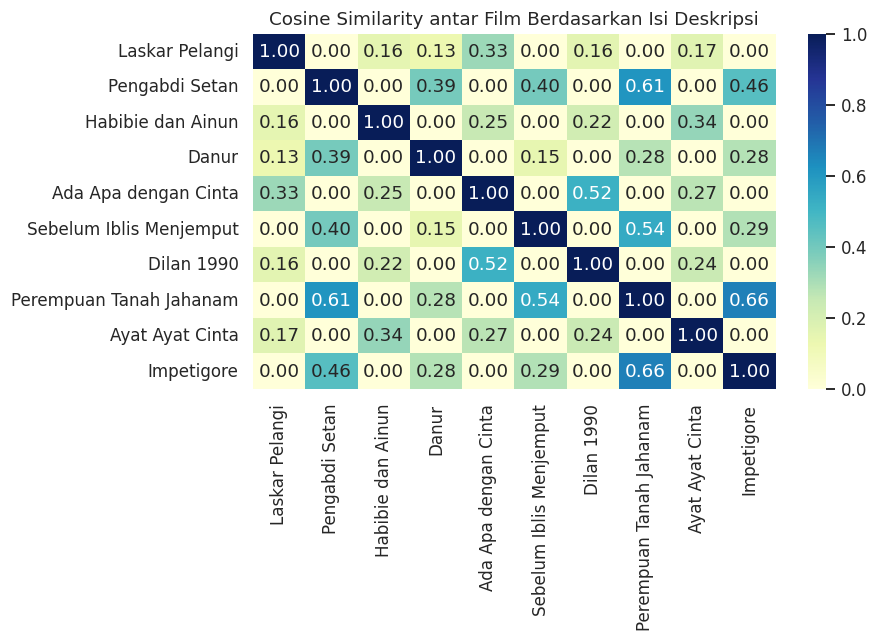

In [18]:
kemiripan_konten = pd.DataFrame(
    cosine_similarity(matriks_tfidf),
    index=katalog['judul'], columns=katalog['judul']
)

plt.figure(figsize=(8.5, 6))
sns.heatmap(kemiripan_konten, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cosine Similarity antar Film Berdasarkan Isi Deskripsi')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [19]:
def rekomendasi_konten(judul, jumlah=3):
    """Merekomendasikan film yang isinya paling mirip dengan film acuan."""
    skor = kemiripan_konten[judul].drop(labels=[judul]).sort_values(ascending=False)
    return skor.head(jumlah).round(3)


for acuan in ['Laskar Pelangi', 'Pengabdi Setan', 'Dilan 1990']:
    print(f'Karena Anda menyukai "{acuan}", maka direkomendasikan:')
    print(rekomendasi_konten(acuan).to_string())
    print()

Karena Anda menyukai "Laskar Pelangi", maka direkomendasikan:
judul
Ada Apa dengan Cinta    0.326
Ayat Ayat Cinta         0.170
Dilan 1990              0.159

Karena Anda menyukai "Pengabdi Setan", maka direkomendasikan:
judul
Perempuan Tanah Jahanam    0.611
Impetigore                 0.455
Sebelum Iblis Menjemput    0.397

Karena Anda menyukai "Dilan 1990", maka direkomendasikan:
judul
Ada Apa dengan Cinta    0.519
Ayat Ayat Cinta         0.239
Habibie dan Ainun       0.218



## 8. Perbandingan Kedua Pendekatan Rekomendasi

| Aspek | Collaborative Filtering | Content-Based Filtering |
| --- | --- | --- |
| Dasar perhitungan | Pola penilaian antar pengguna atau item | Kemiripan isi atau atribut item |
| Kebutuhan data | Riwayat penilaian yang cukup banyak | Deskripsi atau metadata item |
| Masalah cold start | Berat, item baru tidak dapat direkomendasikan | Ringan, cukup ada deskripsi item |
| Keberagaman hasil | Mampu memberi kejutan di luar selera lama | Cenderung monoton, mirip yang sudah disukai |
| Kelemahan utama | Matriks penilaian sangat kosong | Terbatas pada kualitas deskripsi |

Dalam praktik industri keduanya sering digabungkan menjadi **hybrid recommender
system** agar kelemahan masing masing saling tertutupi.

## 9. Kesimpulan

**Apa yang dipelajari.** Praktikum ini mencakup dua topik yang saling berhubungan,
yaitu penemuan aturan asosiasi memakai algoritma Apriori dan pembangunan sistem
rekomendasi dasar. Algoritma Apriori ditulis langsung tanpa pustaka tambahan agar
sifat pemangkasan kandidatnya terlihat jelas, sedangkan sistem rekomendasi dibangun
melalui dua pendekatan yaitu Collaborative Filtering berbasis item dan Content-Based
Filtering berbasis TF-IDF.

**Temuan utama.** Apriori berhasil menemukan kembali seluruh pola pembelian bersama
yang ditanamkan pada data, seperti kopi dengan gula serta roti dengan selai, yang
tampak dari nilai lift antar dua produk yang berkisar antara 1,48 sampai 2,66.
Terlihat pula bahwa aturan dengan lift paling tinggi justru berupa gabungan tiga
produk yang support-nya kecil, sehingga pemilihan aturan untuk dipakai di lapangan
perlu mempertimbangkan support dan lift secara bersamaan, bukan lift saja. Pemangkasan kandidat terbukti bekerja karena
jumlah kandidat yang harus diperiksa menyusut drastis pada setiap tingkat. Dari sisi
rekomendasi, Collaborative Filtering berhasil memisahkan dua kelompok selera pengguna
yaitu penggemar drama dan penggemar horor, sedangkan Content-Based Filtering
menghasilkan rekomendasi yang konsisten dengan genre film acuan. Terlihat pula bahwa
confidence tinggi tidak selalu berarti aturan bermakna, karena produk yang memang
laris untuk semua orang dapat menghasilkan confidence besar dengan lift mendekati satu.

**Keterbatasan dan pertanyaan yang muncul.** Data transaksi maupun data penilaian
bersifat sintetis dengan pola yang sengaja ditanamkan, sehingga hasil pada data nyata
akan jauh lebih berderau dan nilai lift-nya cenderung lebih rendah. Implementasi
Apriori yang ditulis di sini juga memeriksa seluruh transaksi berulang kali sehingga
menjadi lambat bila jumlah produk dan transaksinya sangat besar, dan pada kondisi
tersebut algoritma FP-Growth lebih tepat dipakai. Sistem rekomendasi yang dibangun
belum dievaluasi memakai metrik seperti Precision at K atau RMSE karena belum tersedia
data uji. Pertanyaan yang muncul adalah bagaimana cara mengevaluasi mutu rekomendasi
secara objektif, serta bagaimana menggabungkan kedua pendekatan menjadi sistem hybrid.